### Installing Packages

Research Paper written on the dataset and problem: https://www.researchgate.net/publication/220320916_Causality_Challenge_Benchmarking_relevant_signal_components_for_effective_monitoring_and_process_control

In [1]:
# Install external libraries not included by default in Kaggle notebooks
!pip install ucimlrepo
!pip install imbalanced-learn
!pip install missingno
!pip install xgboost

# Now, import all the necessary libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo
from io import BytesIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer, SimpleImputer
from scipy.stats.mstats import winsorize
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, roc_auc_score, f1_score, classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import randint
from tqdm.notebook import tqdm
import warnings
from sklearn.exceptions import ConvergenceWarning

# Optionally, suppress warnings from showing, especially useful for ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


## Introduction to a Data Science Project on the UCI ML Repository SECOM Dataset

**Dataset Overview:**

This project centers around the analysis of the SECOM dataset, a substantial and detailed collection of data from a semiconductor manufacturing process.

**The first file** contains 1567 rows, with 591 features. These features represent various measurements and sensor readings captured during the manufacturing process.

**The second file** consists of corresponding labels for each row, providing a pass/fail classification along with a date-time stamp that marks the point of each test within the manufacturing cycle.

**Data Characteristics:**

Reflecting real-world data conditions, the SECOM dataset authors alert the Data Scientist embarking on this project of the presence of null values, with the intensity of these missing values varying across different features. This aspect of the dataset is a common challenge in data analysis and will be addressed through thoughtful pre-processing techniques.


### Importing Data from Local Files

In [8]:
def uci_data_request_local(secom_path, secom_labels_path):
    # Read local training data
    data = pd.read_csv(secom_path, sep=" ", header=None)

    # Read local label data
    labels_data = pd.read_csv(secom_labels_path, sep=" ", header=None)

    # Merge the two datasets by index
    df = pd.merge(data, labels_data, left_index=True, right_index=True, how='inner')

    # Rename columns
    df.rename(columns={'0_x': '0', '1_x': '1', '0_y': 'Pass/Fail', '1_y': 'Time'}, inplace=True)

    return df

# Local file paths
train_url = "C:/Users/Yi-TsenLin/Desktop/HTW/25SOSE/Data Analytics II/00_Assignment/Code/secom.data"
labels_url = "C:/Users/Yi-TsenLin/Desktop/HTW/25SOSE/Data Analytics II/00_Assignment/Code/secom_labels.data"

# Load and display data
df = uci_data_request_local(train_url, labels_url)
print(df.shape)
print(df.head())


(1567, 592)
         0        1          2          3       4      5         6       7  \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

        8       9  ...     582     583     584      585     586     587  \
0  1.5005  0.0162  ...  0.5005  0.0118  0.0035   2.3630     NaN     NaN   
1  1.4966 -0.0005  ...  0.5019  0.0223  0.0055   4.4447  0.0096  0.0201   
2  1.4436  0.0041  ...  0.4958  0.0157  0.0039   3.1745  0.0584  0.0484   
3  1.4882 -0.0124  ...  0.4990  0.0103  0.0025   2.0544  0.0202  0.0149   
4  1.5031 -0.0031  ...  0.4800  0.4766  0.1045  99.3032  0.0202  0.0149   

      588       589  Pass/Fail                 Time  
0     NaN     

### Descriptive Analysis


✅ Duplicated Rows: 0
✅ Zero Volatility Columns: 116
✅ Columns with std < 0.01: 55


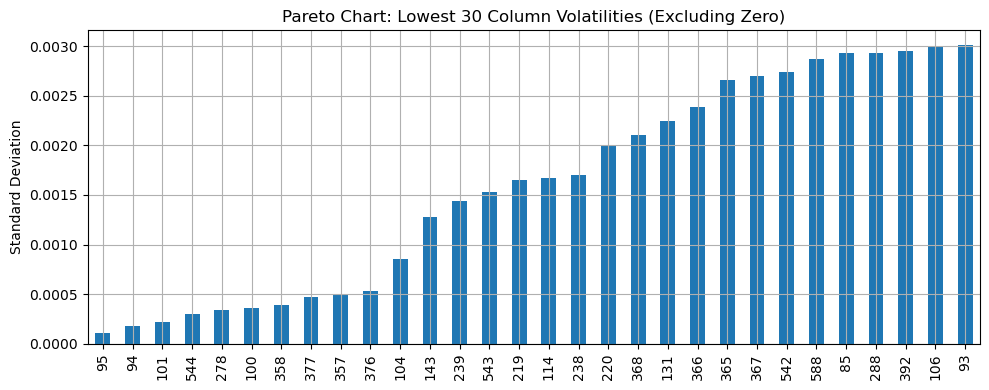

✅ Columns with Missing Values: 538
✅ Maximum Missing in One Column: 1429


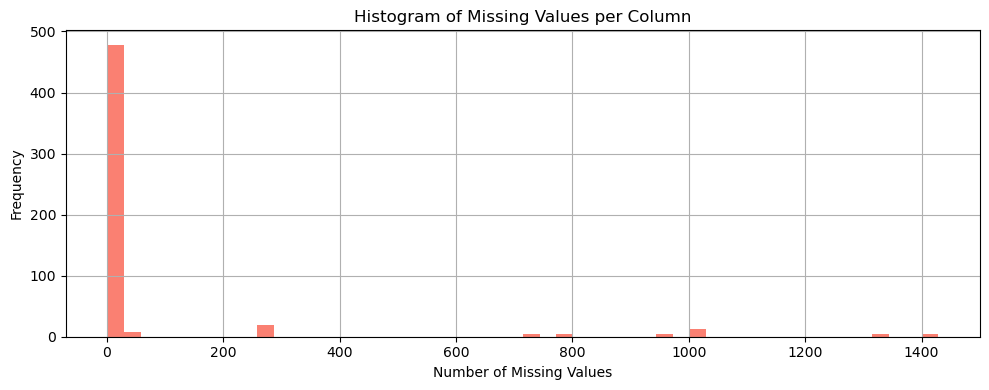

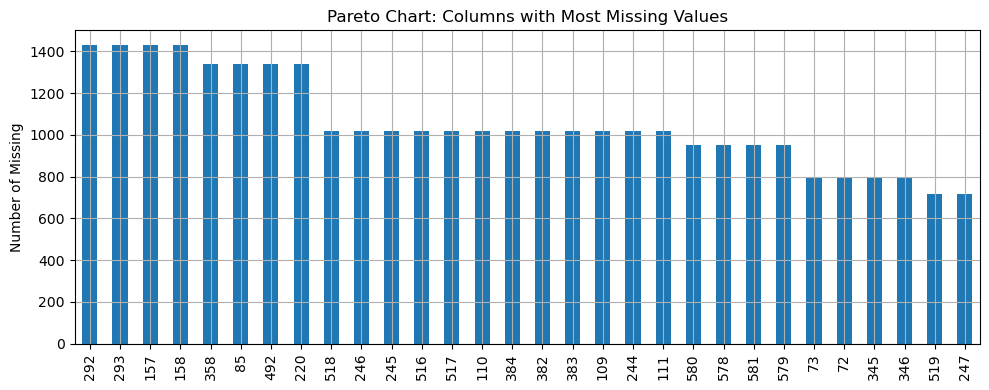

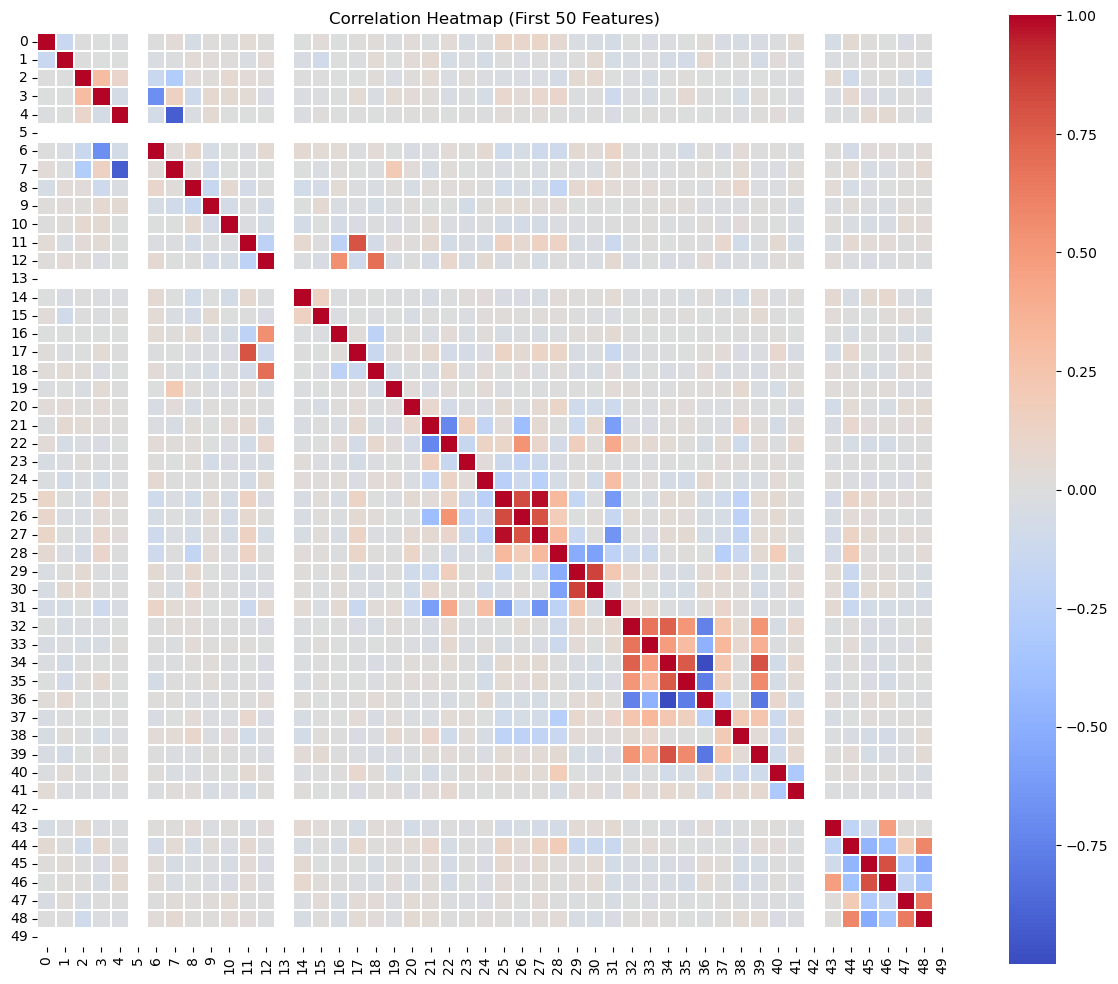

In [9]:
# Extract features (exclude label and timestamp columns)
X_analysis = df.drop(columns=['Pass/Fail', 'Time'])

# If you need the label data, retrieve it like this:
y = df['Pass/Fail']

# === 1. Duplicated Rows ===
num_duplicates = X_analysis.duplicated().sum()
print(f"✅ Duplicated Rows: {num_duplicates}")

# === 2. Zero Volatility Columns ===
std_series = X_analysis.std()
zero_volatility_columns = std_series[std_series == 0].index.tolist()
print(f"✅ Zero Volatility Columns: {len(zero_volatility_columns)}")

# === 3. Low Volatility Column Analysis ===
# Step 2: Compute standard deviation
std_series = X_analysis.std()

# Step 3: Filter out columns with non-zero standard deviation
non_zero_std = std_series[std_series > 0]

# Optional: You can set a threshold; e.g., std < 0.01 is considered "very low volatility"
threshold = 0.01
very_low_volatility = non_zero_std[non_zero_std < threshold]
print(f"✅ Columns with std < {threshold}: {len(very_low_volatility)}")

# Visualize the top 30 lowest-variance columns (excluding zero-variance)
sorted_low_std = non_zero_std.sort_values()
low_volatility_top30 = sorted_low_std.head(30)

# Plot
plt.figure(figsize=(10, 4))
low_volatility_top30.plot(kind='bar')
plt.title("Pareto Chart: Lowest 30 Column Volatilities (Excluding Zero)")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

# === 4. Missing Values Analysis ===
missing_counts = X_analysis.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(f"✅ Columns with Missing Values: {missing_counts.shape[0]}")
print(f"✅ Maximum Missing in One Column: {int(missing_counts.max())}")

# Histogram of missing values
plt.figure(figsize=(10, 4))
plt.hist(missing_counts, bins=50, color='salmon')
plt.title("Histogram of Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Pareto chart: Top 30 columns with most missing values
top_missing = missing_counts.head(30)
plt.figure(figsize=(10, 4))
top_missing.plot(kind='bar')
plt.title("Pareto Chart: Columns with Most Missing Values")
plt.ylabel("Number of Missing")
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

# === 5. Correlation Heatmap (first 50 columns) ===
subset_corr = X_analysis.iloc[:, :50].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(subset_corr, cmap='coolwarm', center=0, square=True, linewidths=0.1)
plt.title("Correlation Heatmap (First 50 Features)")
plt.tight_layout()
plt.show()
